In [1]:
import pandas as pd
import plotnine as p9
p9.options.dpi=300

In [2]:
import numpy as np
import scanpy as sc

In [3]:
import anndata

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches
plt.rcParams['svg.fonttype']='none' 

In [5]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=300)

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/numba/core/cpu.py:97: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2024-04-25 13:36:43.721011: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-25 13:36:43.950658: W tensorflow/tsl/platform/default/dso_loader.cc:66] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared ob

scanpy==1.9.1 anndata==0.7.8 umap==0.5.3 numpy==1.23.5 scipy==1.9.3 pandas==1.5.2 scikit-learn==1.1.3 statsmodels==0.13.5 python-igraph==0.10.2 pynndescent==0.5.8


In [6]:
adata_4lines = anndata.read_h5ad(scifiRNA_directoryname+'/GSM5151353_PD193_fourlines_383k.h5ad')                                

In [7]:
adata_4lines

AnnData object with n_obs × n_vars = 44976860 × 26512
    obs: 'plate_well'

In [8]:
cell_ident_4lines=pd.read_csv(scifiRNA_directoryname+'/GSM5151353_PD193_fourlines_383k.csv.gz',header=0)

In [9]:
adata_4lines.obs=adata_4lines.obs.reset_index().merge(cell_ident_4lines,how="left",left_on=['plate_well'],right_on=["plate_well"]).set_index('index')

In [10]:
adata_4lines.obs

,plate_well,sample_name,combinatorial_barcode,cell_line
index,,,,
A01-AAAAAAAAAAAAGACC,A01,PD193_fourlines_383k_JurkatCas9TCRlib_A01,AAGTGATTAGCAA,JurkatCas9TCRlib
A01-AAAAAAAAAAAATAAA,A01,PD193_fourlines_383k_JurkatCas9TCRlib_A01,AAGTGATTAGCAA,JurkatCas9TCRlib
A01-AAAAAAAAAAATTACA,A01,PD193_fourlines_383k_JurkatCas9TCRlib_A01,AAGTGATTAGCAA,JurkatCas9TCRlib
A01-AAAAAAAAAATAAAAA,A01,PD193_fourlines_383k_JurkatCas9TCRlib_A01,AAGTGATTAGCAA,JurkatCas9TCRlib
A01-AAAAAAAAACTCAATT,A01,PD193_fourlines_383k_JurkatCas9TCRlib_A01,AAGTGATTAGCAA,JurkatCas9TCRlib
...,...,...,...,...
P24-TTTTTTAAGAATATAA,P24,PD193_fourlines_383k_NALM6DSMZ_P24,GCGAGTTTAATGG,NALM6DSMZ
P24-TTTTTTGCTACCAATA,P24,PD193_fourlines_383k_NALM6DSMZ_P24,GCGAGTTTAATGG,NALM6DSMZ
P24-TTTTTTTACTAAAACC,P24,PD193_fourlines_383k_NALM6DSMZ_P24,GCGAGTTTAATGG,NALM6DSMZ


In [11]:
adata_4lines.obs['cell_index']=adata_4lines.obs.index

In [12]:
adata_4lines.obs.cell_line.value_counts()

HEK293T             22178688
K562                 9904909
JurkatCas9TCRlib     9332949
NALM6DSMZ            3560314
Name: cell_line, dtype: int64

In [13]:
PD193_383k_K562_read=pd.read_csv(scifiRNA_directoryname+'/PD193_fourlines_383k_K562_readcount.txt',header=None)

In [14]:
df_PD193_383k_K562_read=PD193_383k_K562_read[0].str.split(expand=True) #default is to split on whitespace

In [15]:
df_PD193_383k_K562_read.columns=['Read_count','Cell_index']

In [16]:
df_PD193_383k_K562_read

,Read_count,Cell_index
0,18256,A02-
1,323,A02-A
2,7,A02-AA
3,16,A02-AAAAAAAAAAAAAAAA
4,2,A02-AAAAAAAAAAAAAAAC
...,...,...
15871391,2,P23-TTTTTTTTCTATTGTC
15871392,1,P23-TTTTTTTTTAGAGATA
15871393,1,P23-TTTTTTTTTATATAGA
15871394,1,P23-TTTTTTTTTCCAACAA


In [17]:
adata_4lines.obs=adata_4lines.obs.reset_index().merge(df_PD193_383k_K562_read,how="left",left_on=["cell_index"],right_on=["Cell_index"]).set_index('index')

In [18]:
PD193_383k_K562_umi=pd.read_csv(scifiRNA_directoryname+'/PD193_fourlines_383k_K562_UMIcount.txt',header=None)

In [19]:
PD193_383k_K562_umi=PD193_383k_K562_umi[0].str.split(expand=True) #default is to split on whitespace

In [20]:
PD193_383k_K562_umi.columns=['UMI_count','Cell_index']

In [21]:
PD193_383k_K562_umi

,UMI_count,Cell_index
0,13725,A02-
1,132,A02-A
2,7,A02-AA
3,16,A02-AAAAAAAAAAAAAAAA
4,2,A02-AAAAAAAAAAAAAAAC
...,...,...
15871391,2,P23-TTTTTTTTCTATTGTC
15871392,1,P23-TTTTTTTTTAGAGATA
15871393,1,P23-TTTTTTTTTATATAGA
15871394,1,P23-TTTTTTTTTCCAACAA


In [22]:
adata_4lines.obs=adata_4lines.obs.reset_index().merge(PD193_383k_K562_umi,how="left",left_on=["cell_index"],right_on=["Cell_index"]).set_index('index')

In [23]:
adata_4lines.obs[adata_4lines.obs.cell_line=='K562']

,plate_well,sample_name,combinatorial_barcode,cell_line,cell_index,Read_count,Cell_index_x,UMI_count,Cell_index_y
index,,,,,,,,,
A02-AAAAAAAAAAAAAAAA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAAAAA,16,A02-AAAAAAAAAAAAAAAA,16,A02-AAAAAAAAAAAAAAAA
A02-AAAAAAAAAAAAAACA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAAACA,5,A02-AAAAAAAAAAAAAACA,5,A02-AAAAAAAAAAAAAACA
A02-AAAAAAAAAAAACAAA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAACAAA,1,A02-AAAAAAAAAAAACAAA,1,A02-AAAAAAAAAAAACAAA
A02-AAAAAAAAAAAACACA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAACACA,1,A02-AAAAAAAAAAAACACA,1,A02-AAAAAAAAAAAACACA
A02-AAAAAAAAAAAAGACT,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAGACT,1,A02-AAAAAAAAAAAAGACT,1,A02-AAAAAAAAAAAAGACT
...,...,...,...,...,...,...,...,...,...
P23-TTTTTTTGTAGATAGA,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTGTAGATAGA,2,P23-TTTTTTTGTAGATAGA,2,P23-TTTTTTTGTAGATAGA
P23-TTTTTTTGTTCTGGCT,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTGTTCTGGCT,1,P23-TTTTTTTGTTCTGGCT,1,P23-TTTTTTTGTTCTGGCT
P23-TTTTTTTTCGAGAACG,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTTCGAGAACG,1,P23-TTTTTTTTCGAGAACG,1,P23-TTTTTTTTCGAGAACG


In [24]:
sc.pp.calculate_qc_metrics(adata_4lines, percent_top=None, log1p=False, inplace=True) # This is faster and does not break the kernel

In [25]:
adata_4lines.obs[adata_4lines.obs.cell_line=='K562']

,plate_well,sample_name,combinatorial_barcode,cell_line,cell_index,Read_count,Cell_index_x,UMI_count,Cell_index_y,n_genes_by_counts,total_counts
index,,,,,,,,,,,
A02-AAAAAAAAAAAAAAAA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAAAAA,16,A02-AAAAAAAAAAAAAAAA,16,A02-AAAAAAAAAAAAAAAA,3,3.0
A02-AAAAAAAAAAAAAACA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAAACA,5,A02-AAAAAAAAAAAAAACA,5,A02-AAAAAAAAAAAAAACA,1,1.0
A02-AAAAAAAAAAAACAAA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAACAAA,1,A02-AAAAAAAAAAAACAAA,1,A02-AAAAAAAAAAAACAAA,1,1.0
A02-AAAAAAAAAAAACACA,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAACACA,1,A02-AAAAAAAAAAAACACA,1,A02-AAAAAAAAAAAACACA,1,1.0
A02-AAAAAAAAAAAAGACT,A02,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,K562,A02-AAAAAAAAAAAAGACT,1,A02-AAAAAAAAAAAAGACT,1,A02-AAAAAAAAAAAAGACT,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
P23-TTTTTTTGTAGATAGA,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTGTAGATAGA,2,P23-TTTTTTTGTAGATAGA,2,P23-TTTTTTTGTAGATAGA,1,1.0
P23-TTTTTTTGTTCTGGCT,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTGTTCTGGCT,1,P23-TTTTTTTGTTCTGGCT,1,P23-TTTTTTTGTTCTGGCT,1,1.0
P23-TTTTTTTTCGAGAACG,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-TTTTTTTTCGAGAACG,1,P23-TTTTTTTTCGAGAACG,1,P23-TTTTTTTTCGAGAACG,1,1.0


In [26]:
adata_4lines.obs.dtypes

plate_well                object
sample_name               object
combinatorial_barcode     object
cell_line                 object
cell_index                object
Read_count                object
Cell_index_x              object
UMI_count                 object
Cell_index_y              object
n_genes_by_counts          int32
total_counts             float32
dtype: object

In [27]:
adata_4lines.obs['Read_count']=adata_4lines.obs['Read_count'].astype('Int64')

In [28]:
adata_4lines.obs['UMI_count']=adata_4lines.obs['UMI_count'].astype('Int64')

In [29]:
adata_4lines.obs[adata_4lines.obs.index=='C16-AGGCCCATCTTGTCAT']

,plate_well,sample_name,combinatorial_barcode,cell_line,cell_index,Read_count,Cell_index_x,UMI_count,Cell_index_y,n_genes_by_counts,total_counts
index,,,,,,,,,,,
C16-AGGCCCATCTTGTCAT,C16,PD193_fourlines_383k_K562_C16,TCGTGAGGGGGTA,K562,C16-AGGCCCATCTTGTCAT,7721,C16-AGGCCCATCTTGTCAT,200,C16-AGGCCCATCTTGTCAT,117,1096.0


In [ ]:
#number of reads is 7721 for this cell:
#view PD193_fourlines_383k_K562.bam | grep r2:Z:AGGCCCATCTTGTCAT | grep C16 | wc -l
#number of UMI seems to be only 200 for this cell:
#samtools view PD193_fourlines_383k_K562.bam | grep r2:Z:AGGCCCATCTTGTCAT | grep C16 | sed's/.*RX:Z:\([ACGT]*\).*/\1/' | sort | uniq -c | wc -l
#This is consistent with the UMI_count column.
#How is total_counts=1096 (summing UMI for all genes)? Unless some UMI are used for multiple genes...?

In [30]:
#Let's take the top 151788 cells, since the filtering based on nUMI>199 does not match the expected 151788 cells.
df_4lines_sorted=adata_4lines.obs.sort_values(by=['total_counts'],ascending=False)

In [31]:
df_4lines_sorted['rank']=range(1,len(df_4lines_sorted)+1,1)

In [32]:
df_4lines_sorted

,plate_well,sample_name,combinatorial_barcode,cell_line,cell_index,Read_count,Cell_index_x,UMI_count,Cell_index_y,n_genes_by_counts,total_counts,rank
index,,,,,,,,,,,,
L11-GCAAAGGGTTTCTTAC,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,L11-GCAAAGGGTTTCTTAC,<NA>,NaN,<NA>,NaN,2029,35188.0,1
M11-ACGTTAGGTAACACTC,M11,PD193_fourlines_383k_HEK293T_M11,CGACCACCTGTAC,HEK293T,M11-ACGTTAGGTAACACTC,<NA>,NaN,<NA>,NaN,2112,29375.0,2
L11-GCGGGTTAGGCAAGCT,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,L11-GCGGGTTAGGCAAGCT,<NA>,NaN,<NA>,NaN,1810,28680.0,3
K19-GGCGTTGGTATCACAC,K19,PD193_fourlines_383k_HEK293T_K19,TCTGCCTACTAAC,HEK293T,K19-GGCGTTGGTATCACAC,<NA>,NaN,<NA>,NaN,1896,26992.0,4
J05-ACTAACGTCTTACGGA,J05,PD193_fourlines_383k_HEK293T_J05,ACGCGGCTCATCA,HEK293T,J05-ACTAACGTCTTACGGA,<NA>,NaN,<NA>,NaN,1761,26570.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
H17-GAACGATCAGTATACC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,H17-GAACGATCAGTATACC,<NA>,NaN,<NA>,NaN,1,1.0,44976856
H17-GAACGATATTTGCCGC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,H17-GAACGATATTTGCCGC,<NA>,NaN,<NA>,NaN,1,1.0,44976857
H17-GAACGATATTGATAAC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,H17-GAACGATATTGATAAC,<NA>,NaN,<NA>,NaN,1,1.0,44976858


In [33]:
df_4lines_sorted[0:151788].cell_line.value_counts() #based on the publication 151788 single-cell transcriptomes were achieved from this experiment

HEK293T             88419
K562                36218
JurkatCas9TCRlib    15443
NALM6DSMZ           11708
Name: cell_line, dtype: int64

In [34]:
df_4lines_filtered=df_4lines_sorted[df_4lines_sorted['rank'] < 151789] #151789 is based on the publication that 151788 single-cell transcriptomes were achieved from this experiment

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/scales/scales.py:169: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/scales/scales.py:169: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


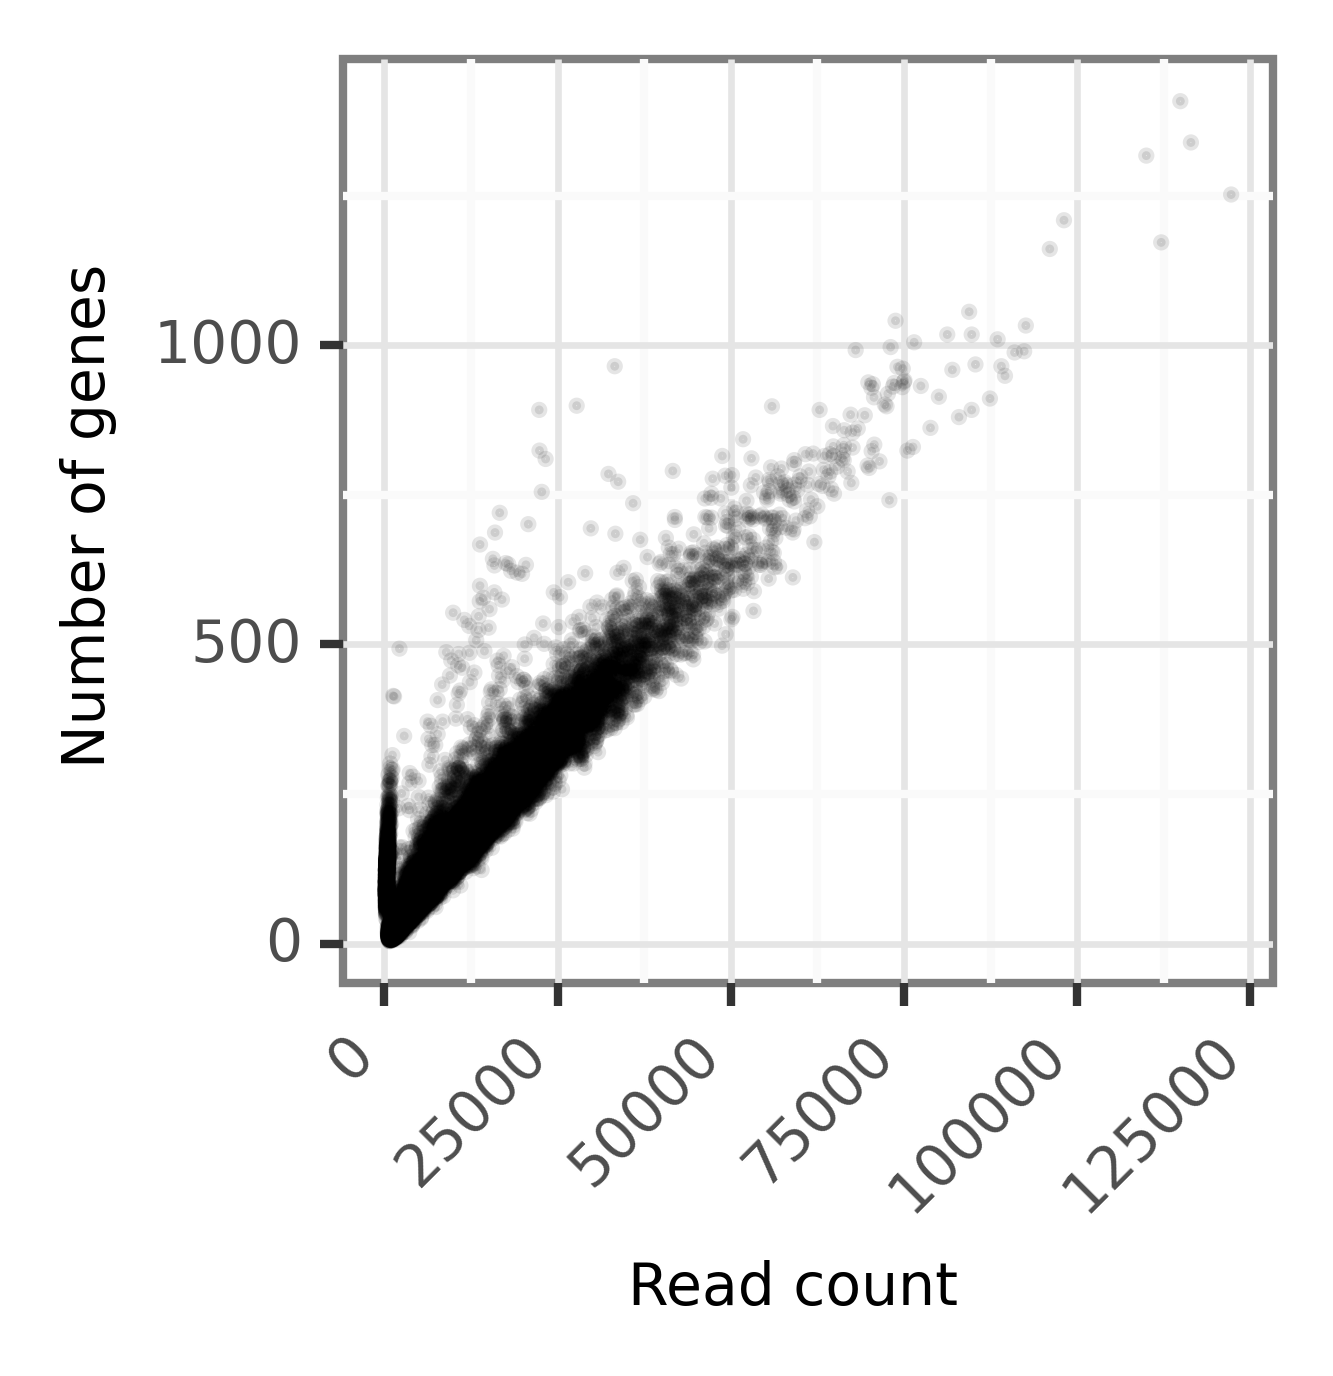

<ggplot: (2932554946807)>

In [35]:
plot=p9.ggplot(data=df_4lines_filtered[df_4lines_filtered.cell_line=='K562' ],
               mapping=p9.aes(x='Read_count',y='n_genes_by_counts')
              )
plot+ p9.geom_point(alpha=0.1,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.labels.ylab('Number of genes') \
+ p9.labels.xlab('Read count') \
+ p9.theme(figure_size=(2,2)) 



/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/scales/scales.py:169: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/scales/scales.py:169: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/scales/scales.py:169: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new ar

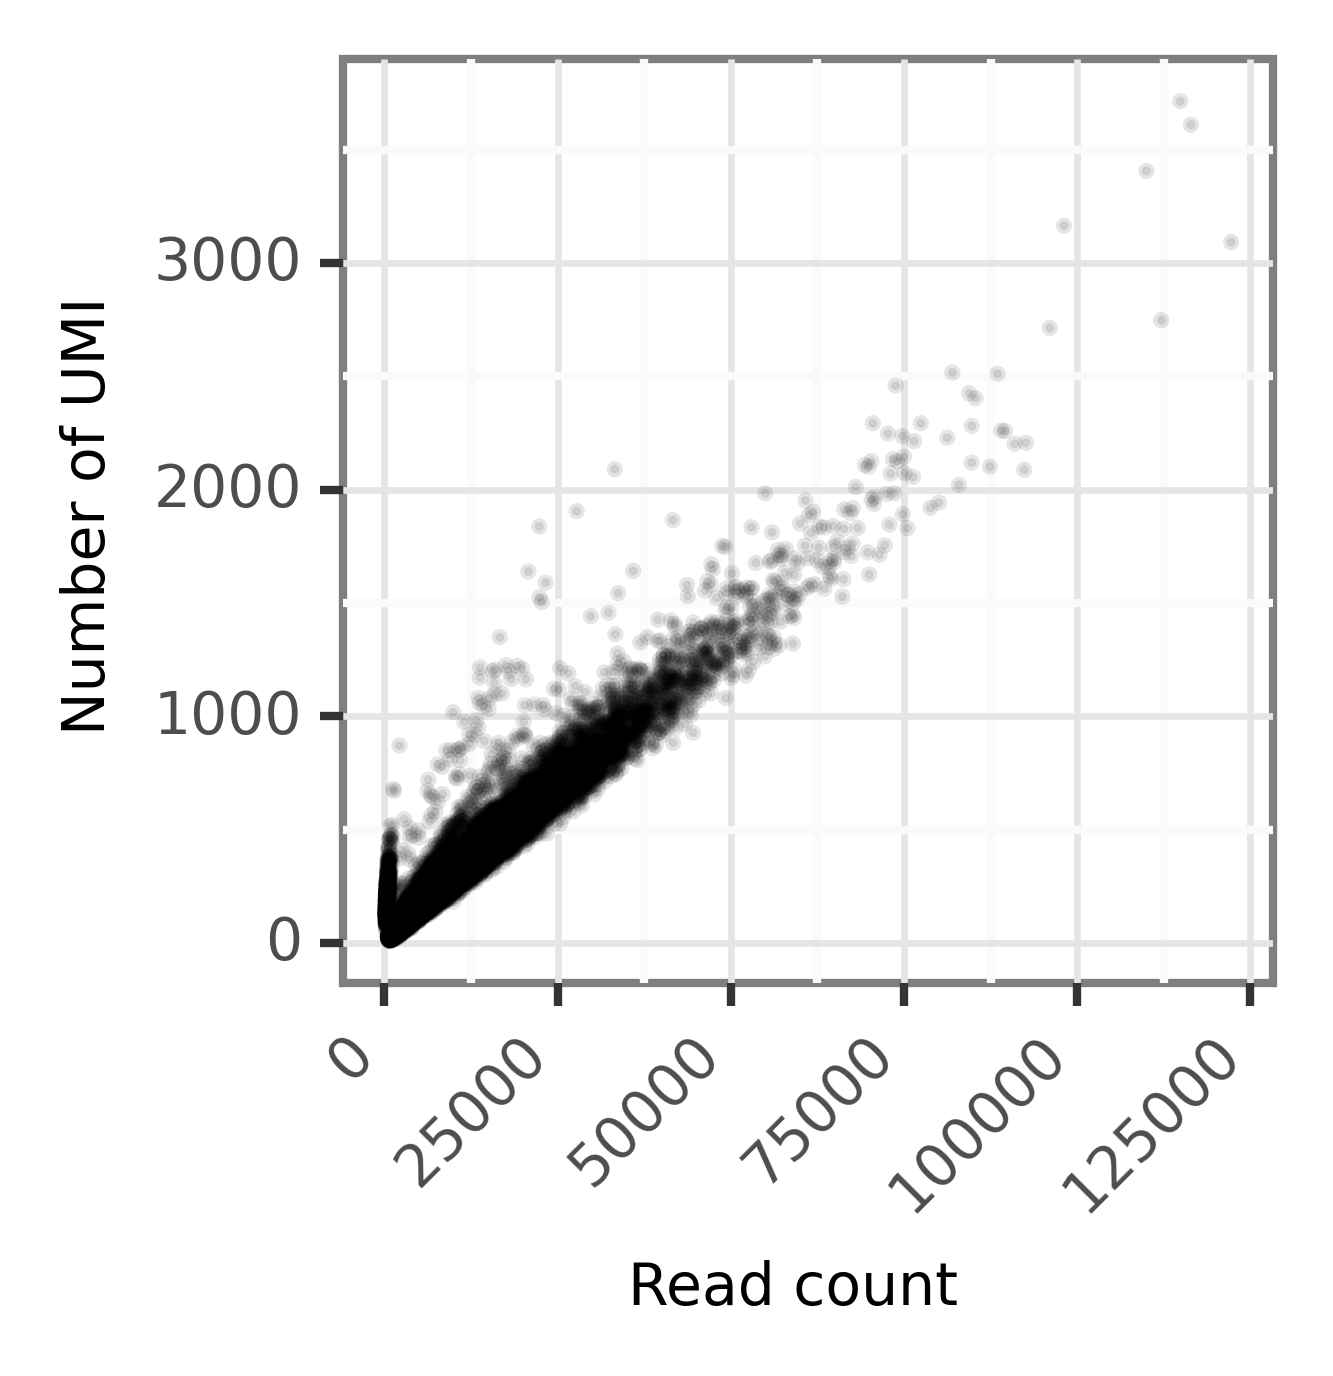

<ggplot: (2932097795515)>

In [38]:
plot=p9.ggplot(data=df_4lines_filtered[df_4lines_filtered.cell_line=='K562' ],
               mapping=p9.aes(x='Read_count',y='UMI_count')
              )
plot+ p9.geom_point(alpha=0.1,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.labels.ylab('Number of UMI') \
+ p9.labels.xlab('Read count') \
+ p9.theme(figure_size=(2,2)) 



In [39]:
df_4lines_filtered[df_4lines_filtered.cell_line=='K562' ]

,plate_well,sample_name,combinatorial_barcode,cell_line,cell_index,Read_count,Cell_index_x,UMI_count,Cell_index_y,n_genes_by_counts,total_counts,rank
index,,,,,,,,,,,,
B14-TACGGATAGAAGGGCG,B14,PD193_fourlines_383k_K562_B14,ACGCGCAAACAGA,K562,B14-TACGGATAGAAGGGCG,114878,B14-TACGGATAGAAGGGCG,3714,B14-TACGGATAGAAGGGCG,1408,18808.0,30
D20-AACGGGAAGGGTTCTT,D20,PD193_fourlines_383k_K562_D20,TCCTCCTTTACGC,K562,D20-AACGGGAAGGGTTCTT,116404,D20-AACGGGAAGGGTTCTT,3610,D20-AACGGGAAGGGTTCTT,1339,17570.0,47
D14-CTTGTCGAGAGTGGTC,D14,PD193_fourlines_383k_K562_D14,TCAGTGCGCTGTC,K562,D14-CTTGTCGAGAGTGGTC,109969,D14-CTTGTCGAGAGTGGTC,3406,D14-CTTGTCGAGAGTGGTC,1317,17178.0,54
P23-GCGTTGGCACTCGGAC,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-GCGTTGGCACTCGGAC,98085,P23-GCGTTGGCACTCGGAC,3164,P23-GCGTTGGCACTCGGAC,1209,17150.0,55
A24-ACATGGTCAGTCAGAG,A24,PD193_fourlines_383k_K562_A24,AGAGGACGATGCA,K562,A24-ACATGGTCAGTCAGAG,122211,A24-ACATGGTCAGTCAGAG,3092,A24-ACATGGTCAGTCAGAG,1252,16483.0,66
...,...,...,...,...,...,...,...,...,...,...,...,...
P23-ACTATTCGTCCATTGA,P23,PD193_fourlines_383k_K562_P23,GAACTTCGAAAAG,K562,P23-ACTATTCGTCCATTGA,848,P23-ACTATTCGTCCATTGA,30,P23-ACTATTCGTCCATTGA,20,147.0,151766
O09-AACAGTCGTACTAGAA,O09,PD193_fourlines_383k_K562_O09,GGCTGCCGTCACG,K562,O09-AACAGTCGTACTAGAA,817,O09-AACAGTCGTACTAGAA,15,O09-AACAGTCGTACTAGAA,7,147.0,151774
C24-TTGCTTACAATTGCCA,C24,PD193_fourlines_383k_K562_C24,TCTCCTAAGCTCC,K562,C24-TTGCTTACAATTGCCA,1373,C24-TTGCTTACAATTGCCA,30,C24-TTGCTTACAATTGCCA,16,147.0,151777


In [40]:
df_4lines_filtered[df_4lines_filtered.cell_line=='K562' ].to_csv(outputdir+'/ScifiRNA/PD193_383k_K562.csv',header=True,index=False)